# CWRU End-to-End STFT Training

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# CWRU four-class classification with an end-to-end STFT model

This notebook trains directly from raw CWRU Drive-End (DE) recordings. It does **not** save or load precomputed spectrograms.

`EndToEndSTFTClassifier.forward()` performs, on every batch:

1. split each raw recording into overlapping fixed-length segments;
2. normalize each segment;
3. compute its log-magnitude STFT;
4. apply a 2-D CNN to the spectrogram; and
5. average segment logits into one recording-level prediction.

The four labels are: normal, outer-race fault, inner-race fault, and ball fault. The split is by source recording, never by already-overlapping windows, so windows from one `.mat` file cannot leak into validation.

In [2]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.signal import decimate
from scipy.signal import firwin
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Change these paths when running locally. Keeping the two roots also handles Normal files.
DATA_ROOTS = [
    Path('/content/drive/MyDrive/CWRU-dataset-main/12k_Drive_End_Bearing_Fault_Data'),
    Path('/content/drive/MyDrive/CWRU-dataset-main/Normal'),
]

CLASS_NAMES = ['normal', 'outer race', 'inner race', 'ball']
NUM_CLASSES = len(CLASS_NAMES)
LABEL_KEYWORDS = {'normal': 0, 'outer': 1, 'or': 1, 'inner': 2, 'ir': 2, 'ball': 3, 'b': 3}

# Parameters used INSIDE the model forward pass.
SEGMENT_LENGTH = 4096
SEGMENT_HOP = 2048
N_FFT = 256
STFT_HOP = 64
STFT_WIN_LENGTH = 256

HELD_OUT_LOAD_HP = 2
VALIDATION_FRACTION = 0.20
BATCH_SIZE = 4              # safe now that padding no longer pollutes BatchNorm
EPOCHS = 60
LEARNING_RATE = 1e-3
WINDOW_CHUNK_SIZE = 128
EARLY_STOP_PATIENCE = 12

# In-model augmentation (training only)
AUGMENT = True
NOISE_STD = 0.02            # relative to normalized segment std
MAX_SHIFT_FRACTION = 0.10   # circular shift up to 10% of segment length
FREQ_MASK_FRACTION = 0.15   # SpecAugment-style masking
TIME_MASK_FRACTION = 0.15

BAND_EDGES = [
    (300, 1500),
    (1500, 3000),
    (3000, 5500),
]
BANDPASS_TAPS = 129

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Device: cuda


In [3]:
from scipy.signal import resample_poly
from fractions import Fraction

# Approximate CWRU shaft speeds by load (standard published values).
CWRU_LOAD_RPM = {0: 1797, 1: 1772, 2: 1750, 3: 1730}
REFERENCE_RPM = CWRU_LOAD_RPM[0]  # order-track every recording to look like the 0 hp condition


def order_track_resample(signal: np.ndarray, actual_rpm: int, reference_rpm: int = REFERENCE_RPM) -> np.ndarray:
    """Resample so one shaft revolution spans the same number of samples regardless of load.
    This pins load-dependent fault frequencies (multiples of shaft speed) to consistent bins."""
    ratio = Fraction(reference_rpm, actual_rpm).limit_denominator(1000)
    if ratio.numerator == ratio.denominator:
        return signal
    return resample_poly(signal, ratio.numerator, ratio.denominator).astype(np.float32)

In [4]:
NORMAL_SAMPLE_RATE_HZ = 48000
FAULT_SAMPLE_RATE_HZ = 12000
NORMAL_DOWNSAMPLE_FACTOR = NORMAL_SAMPLE_RATE_HZ // FAULT_SAMPLE_RATE_HZ  # 4

In [5]:
def load_de_signal(mat_path: str | Path) -> np.ndarray:
    """Load the single Drive-End acceleration channel from one CWRU .mat file."""
    mat_path = Path(mat_path)
    contents = loadmat(mat_path)
    keys = sorted(key for key in contents if key.lower().endswith('_de_time'))
    if len(keys) == 0:
        raise ValueError(f'No *_DE_time channel found in {mat_path}')
    if len(keys) == 1:
        return np.asarray(contents[keys[0]], dtype=np.float32).reshape(-1)

    # Some CWRU normal-baseline .mat files carry a leftover extra *_DE_time
    # variable from how the dataset was originally assembled. Disambiguate by
    # matching the key's numeric id to the filename's numeric id.
    file_match = re.search(r'\d+', mat_path.stem)
    if file_match:
        target_id = file_match.group().lstrip('0') or '0'
        for key in keys:
            key_match = re.search(r'\d+', key)
            if key_match and key_match.group().lstrip('0') == target_id:
                return np.asarray(contents[key], dtype=np.float32).reshape(-1)

    warnings.warn(f'Multiple DE_time channels in {mat_path}; using {keys[-1]} of {keys}')
    return np.asarray(contents[keys[-1]], dtype=np.float32).reshape(-1)

def label_from_path(mat_path: Path, root: Path) -> int | None:
    # Match folder names such as B, IR, OR, and the standalone Normal root.
    parts = (root.name, *mat_path.relative_to(root).parts)
    for keyword, label in LABEL_KEYWORDS.items():
        if any(part.lower().startswith(keyword) for part in parts):
            return label
    return None


def load_condition_from_group_id(group_id: str) -> int:
    """Read the CWRU motor load (0--3 hp) from its standard filename."""
    filename = Path(group_id).name
    fault_match = re.search(r'_([0-3])\.mat$', filename, re.IGNORECASE)
    if fault_match:
        return int(fault_match.group(1))
    normal_loads = {'97.mat': 0, '98.mat': 1, '99.mat': 2, '100.mat': 3}
    if filename in normal_loads:
        return normal_loads[filename]
    raise ValueError(f'Cannot infer CWRU load condition from {group_id}')


def build_recording_dataset(data_roots=DATA_ROOTS, min_length=SEGMENT_LENGTH):
    """Return variable-length raw signals, labels, and one ID per source .mat file."""
    signals, labels, group_ids = [], [], []
    for root_value in data_roots:
        root = Path(root_value)
        if not root.is_dir():
            warnings.warn(f'Dataset root does not exist; skipping: {root}')
            continue
        for mat_path in sorted(root.rglob('*.mat')):
            label = label_from_path(mat_path, root)
            if label is None:
                warnings.warn(f'No class label matched; skipping: {mat_path}')
                continue
            signal = load_de_signal(mat_path)
            if root.name.lower() == 'normal':
                signal = decimate(signal, NORMAL_DOWNSAMPLE_FACTOR, ftype='iir', zero_phase=True).astype(np.float32)
            load_hp = load_condition_from_group_id(mat_path.name)
            signal = order_track_resample(signal, CWRU_LOAD_RPM[load_hp])
            if len(signal) < min_length:
                warnings.warn(f'Recording shorter than one segment; skipping: {mat_path}')
                continue
            signals.append(signal)
            labels.append(label)
            group_ids.append(f'{root.name}/{mat_path.relative_to(root).as_posix()}')
    if not signals:
        raise RuntimeError('No recordings found. Edit DATA_ROOTS to point to the CWRU dataset.')
    return signals, np.asarray(labels, dtype=np.int64), np.asarray(group_ids, dtype=object)

Recordings: 64
Recordings per class: {'normal': 4, 'outer race': 28, 'inner race': 16, 'ball': 16}
Raw length range: 60,985 to 127,678 samples


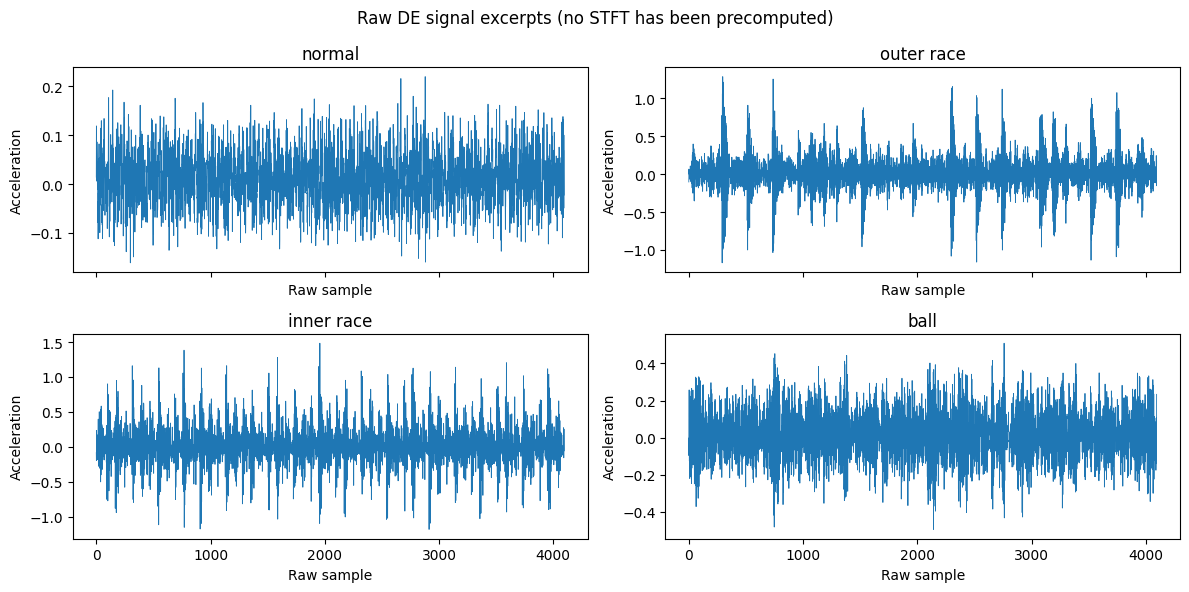

In [6]:
signals, labels, group_ids = build_recording_dataset()
print(f'Recordings: {len(signals)}')
print('Recordings per class:', {CLASS_NAMES[k]: v for k, v in sorted(Counter(labels).items())})
print(f'Raw length range: {min(map(len, signals)):,} to {max(map(len, signals)):,} samples')

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for axis, class_id in zip(axes.flat, range(NUM_CLASSES)):
    index = np.flatnonzero(labels == class_id)[0]
    axis.plot(signals[index][:4096], linewidth=0.6)
    axis.set_title(CLASS_NAMES[class_id])
    axis.set_xlabel('Raw sample')
    axis.set_ylabel('Acceleration')
fig.suptitle('Raw DE signal excerpts (no STFT has been precomputed)')
fig.tight_layout()
plt.show()

In [7]:
class RawRecordingDataset(Dataset):
    """Deliberately returns raw, variable-length recordings: no windows or STFTs here."""
    def __init__(self, signals, labels, group_ids, indices):
        self.signals = [torch.as_tensor(signals[i], dtype=torch.float32) for i in indices]
        self.labels = torch.as_tensor(labels[indices], dtype=torch.long)
        self.group_ids = group_ids[indices]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.signals[index], self.labels[index], self.group_ids[index]


def collate_raw_recordings(batch):
    raw_signals, batch_labels, batch_group_ids = zip(*batch)
    lengths = torch.as_tensor([len(signal) for signal in raw_signals], dtype=torch.long)
    # Zero padding is only for batching. lengths masks padded/invalid segments in the model.
    padded_raw = pad_sequence(raw_signals, batch_first=True)
    return padded_raw, lengths, torch.stack(batch_labels), batch_group_ids

In [8]:
from scipy.signal import hilbert

## The model: segmentation + STFT + CNN in one `forward()`

The STFT is a fixed, differentiable signal transform; the CNN and classifier parameters are learned. `lengths` prevents zero padding and incomplete final segments from contributing to a recording prediction.

In [9]:
class EndToEndSTFTClassifier(nn.Module):
    """Classify raw, variable-length DE recordings with internal STFT preprocessing."""
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        segment_length=SEGMENT_LENGTH,
        segment_hop=SEGMENT_HOP,
        n_fft=N_FFT,
        stft_hop=STFT_HOP,
        stft_win_length=STFT_WIN_LENGTH,
        window_chunk_size=WINDOW_CHUNK_SIZE,
        augment=AUGMENT,
        noise_std=NOISE_STD,
        max_shift_fraction=MAX_SHIFT_FRACTION,
        freq_mask_fraction=FREQ_MASK_FRACTION,
        time_mask_fraction=TIME_MASK_FRACTION,
    ):
        super().__init__()
        if segment_hop <= 0 or segment_length < stft_win_length:
            raise ValueError('Check segment and STFT sizes.')
        self.segment_length = segment_length
        self.segment_hop = segment_hop
        self.n_fft = n_fft
        self.stft_hop = stft_hop
        self.stft_win_length = stft_win_length
        self.window_chunk_size = window_chunk_size
        self.augment = augment
        self.noise_std = noise_std
        self.max_shift_fraction = max_shift_fraction
        self.freq_mask_fraction = freq_mask_fraction
        self.time_mask_fraction = time_mask_fraction
        self.register_buffer('stft_window', torch.hann_window(stft_win_length))

        self.num_bands = len(BAND_EDGES)
        band_kernels = [
            firwin(
                BANDPASS_TAPS,
                [low_hz, high_hz],
                fs=FAULT_SAMPLE_RATE_HZ,
                pass_zero=False
            )
            for low_hz, high_hz in BAND_EDGES
        ]

        # Shape [num_bands, 1, taps]: conv1d with this weight applies every band's
        # filter to the same single-channel input in one pass, producing num_bands outputs.
        self.register_buffer('multiband_kernel', torch.tensor(np.stack(band_kernels), dtype=torch.float32).unsqueeze(1))

        total_channels = 2 + self.num_bands  # raw + full-band envelope + one envelope per band
        self.spectrogram_cnn = nn.Sequential(
            nn.Conv2d(total_channels, 32, 3, padding=1), nn.GroupNorm(8, 32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(8, 128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(nn.Dropout(0.30), nn.Linear(128, num_classes))
        self.attention = nn.Sequential(nn.Linear(128, 64), nn.Tanh(), nn.Linear(64, 1))

    def _segment_recordings(self, raw, lengths):
        if raw.size(1) < self.segment_length:
            raw = torch.nn.functional.pad(raw, (0, self.segment_length - raw.size(1)))
        segments = raw.unfold(-1, self.segment_length, self.segment_hop)
        valid_counts = ((lengths - self.segment_length) // self.segment_hop + 1).clamp(min=0)
        valid_mask = torch.arange(segments.size(1), device=raw.device)[None, :] < valid_counts[:, None]
        return segments, valid_mask

    def _augment_raw(self, segments):
        # Random circular shift, per segment, then small additive noise.
        if self.max_shift_fraction > 0:
            max_shift = max(1, int(self.segment_length * self.max_shift_fraction))
            shifts = torch.randint(-max_shift, max_shift + 1, (segments.size(0),), device=segments.device)
            segments = torch.stack([torch.roll(s, int(sh.item())) for s, sh in zip(segments, shifts)])
        return segments

    def _augment_spectrogram(self, spec):
        # spec: [segments, 1, freq, time]. Zero out random frequency/time stripes.
        n_freq, n_time = spec.size(2), spec.size(3)
        if self.freq_mask_fraction > 0:
            f_width = max(1, int(n_freq * self.freq_mask_fraction))
            f_start = random.randint(0, max(0, n_freq - f_width))
            spec[:, :, f_start:f_start + f_width, :] = 0.0
        if self.time_mask_fraction > 0:
            t_width = max(1, int(n_time * self.time_mask_fraction))
            t_start = random.randint(0, max(0, n_time - t_width))
            spec[:, :, :, t_start:t_start + t_width] = 0.0
        return spec

    def _multiband_filter(self, segments):
        # segments: [n, length] -> [n, num_bands, length], one filtered copy per band.
        x = segments.unsqueeze(1)  # [n, 1, length]
        pad = self.multiband_kernel.size(-1) // 2
        filtered = torch.nn.functional.conv1d(x, self.multiband_kernel, padding=pad)
        return filtered[..., :segments.size(-1)]

    def _envelope_raw(self, filtered_or_raw):
        # Shared Hilbert-envelope math; caller decides whether to bandpass first.
        n = filtered_or_raw.size(-1)
        spectrum = torch.fft.fft(filtered_or_raw, dim=-1)
        h = torch.zeros(n, device=filtered_or_raw.device, dtype=filtered_or_raw.dtype)
        if n % 2 == 0:
            h[0] = 1.0; h[1:n // 2] = 2.0; h[n // 2] = 1.0
        else:
            h[0] = 1.0; h[1:(n + 1) // 2] = 2.0
        analytic = torch.fft.ifft(spectrum * h, dim=-1)
        envelope = analytic.abs()
        return envelope - envelope.mean(dim=-1, keepdim=True)

    def _envelope_fullband(self, segments):
        return self._envelope_raw(segments)  # no bandpass — full-spectrum envelope

    def _stft_channel(self, segments):
        stft = torch.stft(
            segments, n_fft=self.n_fft, hop_length=self.stft_hop,
            win_length=self.stft_win_length, window=self.stft_window,
            center=False, return_complex=True,
        )
        return torch.log1p(stft.abs()).unsqueeze(1)  # [segments, 1, freq, time]

    # a helper for running STFT over the multi-band tensor
    def _stft_multi(self, x):
        # x: [n, num_bands, length] -> [n, num_bands, freq, time]
        n, b, length = x.shape
        flat = x.reshape(n * b, length)
        spec = self._stft_channel(flat).squeeze(1)  # [n*b, freq, time]
        return spec.view(n, b, spec.size(-2), spec.size(-1))

    def segment_to_log_stft(self, segments):
        segments = (segments - segments.mean(dim=-1, keepdim=True)) / segments.std(dim=-1, keepdim=True).clamp_min(1e-6)
        if self.training and self.noise_std > 0:
            segments = segments + torch.randn_like(segments) * self.noise_std

        raw_spec = self._stft_channel(segments)  # [n, 1, F, T]

        env_full = self._envelope_fullband(segments)
        env_full = env_full / env_full.std(dim=-1, keepdim=True).clamp_min(1e-6)
        env_full_spec = self._stft_channel(env_full)  # [n, 1, F, T]

        band_filtered = self._multiband_filter(segments)  # [n, num_bands, length]
        band_envelopes = self._envelope_raw(band_filtered)  # [n, num_bands, length]
        band_envelopes = band_envelopes / band_envelopes.std(dim=-1, keepdim=True).clamp_min(1e-6)
        band_spec = self._stft_multi(band_envelopes)  # [n, num_bands, F, T]

        spec = torch.cat([raw_spec, env_full_spec, band_spec], dim=1)  # [n, 2+num_bands, F, T]
        if self.training:
            spec = self._augment_spectrogram(spec)
        return spec

    def forward(self, raw, lengths, return_segment_logits=False):
        segments, valid_mask = self._segment_recordings(raw, lengths)
        batch_size, n_segments, segment_length = segments.shape

        flat_segments = segments.reshape(-1, segment_length)
        flat_valid = valid_mask.reshape(-1)
        valid_segments = flat_segments[flat_valid]

        if self.training and self.max_shift_fraction > 0:
            valid_segments = self._augment_raw(valid_segments)

        spectrograms = self.segment_to_log_stft(valid_segments)

        features = []
        for spectrogram_chunk in spectrograms.split(self.window_chunk_size):
            chunk_features = self.spectrogram_cnn(spectrogram_chunk).flatten(1)
            features.append(chunk_features)
        valid_features = torch.cat(features)          # [n_valid_segments, 128]
        valid_logits = self.classifier(valid_features)  # [n_valid_segments, num_classes]

        if return_segment_logits:
            batch_index = torch.arange(batch_size, device=raw.device)
            batch_index = batch_index.unsqueeze(1).expand(batch_size, n_segments).reshape(-1)[flat_valid]
            return valid_logits, batch_index

        # Scatter per-segment features and logits back into [batch, n_segments, ...].
        feat_dim = valid_features.size(-1)
        segment_features = torch.zeros(batch_size * n_segments, feat_dim, device=raw.device, dtype=valid_features.dtype)
        segment_features[flat_valid] = valid_features
        segment_features = segment_features.view(batch_size, n_segments, feat_dim)

        segment_logits_full = torch.zeros(batch_size * n_segments, valid_logits.size(-1), device=raw.device, dtype=valid_logits.dtype)
        segment_logits_full[flat_valid] = valid_logits
        segment_logits_full = segment_logits_full.view(batch_size, n_segments, -1)

        # Learned attention over segments, replacing the flat average.
        attn_scores = self.attention(segment_features).squeeze(-1)  # [batch, n_segments]
        attn_scores = attn_scores.masked_fill(~valid_mask, float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)  # [batch, n_segments, 1]

        recording_logits = (segment_logits_full * attn_weights).sum(dim=1)  # [batch, num_classes]
        return torch.log_softmax(recording_logits, dim=-1)

Raw batch: (4, 126716)
Lengths: [124821, 126415, 125119, 126716]
Recording logits: (4, 4)


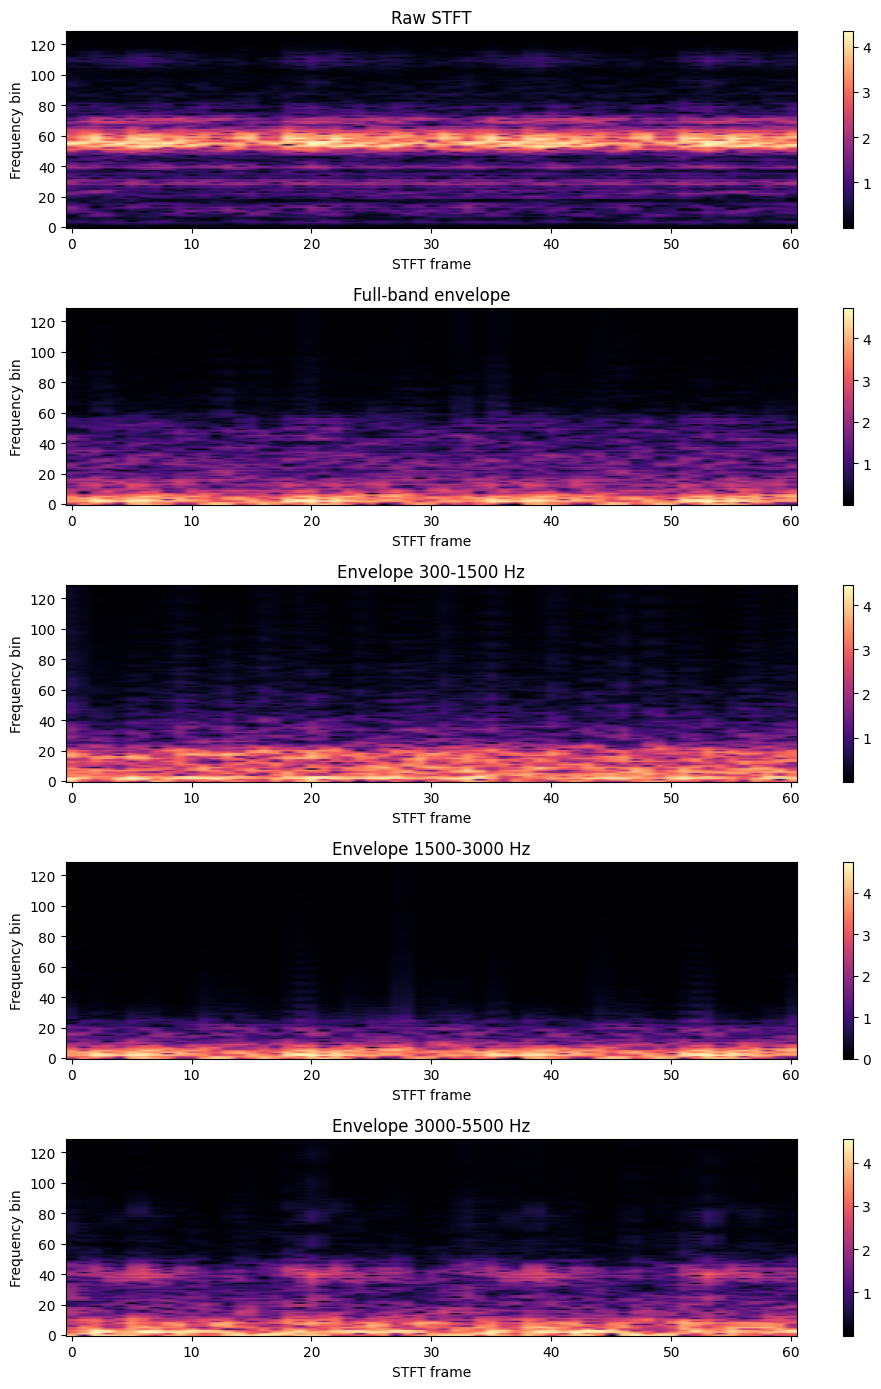

In [10]:
# Confirm that raw recordings, not stored images, reach the model. Standalone sanity check.
sample_indices = np.flatnonzero(np.asarray([load_condition_from_group_id(g) for g in group_ids]) != 0)
sanity_loader = DataLoader(
    RawRecordingDataset(signals, labels, group_ids, sample_indices),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_raw_recordings,
)

model = EndToEndSTFTClassifier().to(DEVICE)
model.eval()
raw_batch, lengths_batch, labels_batch, _ = next(iter(sanity_loader))
with torch.no_grad():
    logits = model(raw_batch.to(DEVICE), lengths_batch.to(DEVICE))
print('Raw batch:', tuple(raw_batch.shape))
print('Lengths:', lengths_batch.tolist())
print('Recording logits:', tuple(logits.shape))

# Inspect one internally generated spectrogram without writing it to disk.
one_segment = raw_batch[0, :SEGMENT_LENGTH].unsqueeze(0).to(DEVICE)
with torch.no_grad():
    spec = model.segment_to_log_stft(one_segment)[0].cpu().numpy()

channel_names = [
    'Raw STFT',
    'Full-band envelope',
    'Envelope 300-1500 Hz',
    'Envelope 1500-3000 Hz',
    'Envelope 3000-5500 Hz',
]

fig, axes = plt.subplots(5, 1, figsize=(10, 14))

for i, (ax, name) in enumerate(zip(axes, channel_names)):
    im = ax.imshow(
        spec[i],
        origin='lower',
        aspect='auto',
        cmap='magma'
    )
    ax.set_title(name)
    ax.set_xlabel('STFT frame')
    ax.set_ylabel('Frequency bin')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

  Saved deployment_checkpoints/heldout0_seed42.pt
  Saved deployment_checkpoints/heldout1_seed42.pt
  Saved deployment_checkpoints/heldout2_seed42.pt
  Saved deployment_checkpoints/heldout3_seed42.pt
Seed 42: fold accuracies [0.75, 0.75, 0.875, 0.875], pooled 0.8125
  Saved deployment_checkpoints/heldout0_seed43.pt
  Saved deployment_checkpoints/heldout1_seed43.pt
  Saved deployment_checkpoints/heldout2_seed43.pt
  Saved deployment_checkpoints/heldout3_seed43.pt
Seed 43: fold accuracies [0.75, 0.875, 0.75, 0.812], pooled 0.7969
  Saved deployment_checkpoints/heldout0_seed44.pt
  Saved deployment_checkpoints/heldout1_seed44.pt
  Saved deployment_checkpoints/heldout2_seed44.pt
  Saved deployment_checkpoints/heldout3_seed44.pt
Seed 44: fold accuracies [0.812, 0.875, 0.688, 0.812], pooled 0.7969

Across 3 seeds: mean pooled accuracy 0.8021 ± 0.0074
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         4
  outer race       0.70      0.93 

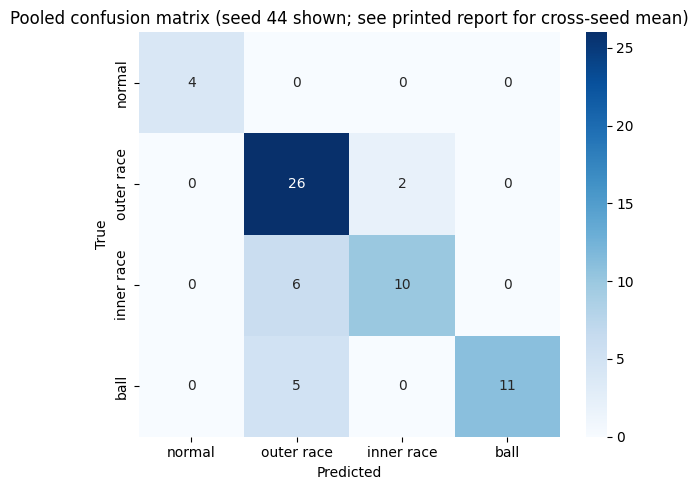

In [11]:
from copy import deepcopy
import os

SEEDS = [42, 43, 44]
seed_pooled_accuracies = []
last_run_truth, last_run_predictions = None, None  # kept for a confusion matrix from the final seed
fold_models = {load: [] for load in [0, 1, 2, 3]}  # holds every seed's trained model per held-out load

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    all_truth, all_predictions, fold_accuracies = [], [], []

    for held_out_load in [0, 1, 2, 3]:
        loads = np.asarray([load_condition_from_group_id(g) for g in group_ids])
        train_indices = np.flatnonzero(loads != held_out_load)
        val_indices = np.flatnonzero(loads == held_out_load)

        train_loader = DataLoader(
            RawRecordingDataset(signals, labels, group_ids, train_indices),
            batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_raw_recordings,
        )
        val_loader = DataLoader(
            RawRecordingDataset(signals, labels, group_ids, val_indices),
            batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_raw_recordings,
        )

        model = EndToEndSTFTClassifier().to(DEVICE)
        train_label_counts = Counter(labels[train_indices].tolist())
        class_weights = torch.tensor(
            [len(train_indices) / (NUM_CLASSES * train_label_counts.get(c, 1)) for c in range(NUM_CLASSES)],
            dtype=torch.float32,
        ).to(DEVICE)
        segment_criterion = nn.CrossEntropyLoss(weight=class_weights)
        recording_criterion = nn.NLLLoss(weight=class_weights)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

        best_val_loss, best_state, epochs_without_improvement = float('inf'), None, 0
        for epoch in range(1, EPOCHS + 1):
            model.train()
            for raw, lengths, targets, _ in train_loader:
                raw, lengths, targets = raw.to(DEVICE), lengths.to(DEVICE), targets.to(DEVICE)
                optimizer.zero_grad(set_to_none=True)
                segment_logits, batch_index = model(raw, lengths, return_segment_logits=True)
                loss = segment_criterion(segment_logits, targets[batch_index])
                loss.backward()
                optimizer.step()

            model.eval()
            val_loss_sum, val_count = 0, 0
            with torch.no_grad():
                for raw, lengths, targets, _ in val_loader:
                    raw, lengths, targets = raw.to(DEVICE), lengths.to(DEVICE), targets.to(DEVICE)
                    log_probs = model(raw, lengths)
                    val_loss_sum += recording_criterion(log_probs, targets).item() * len(targets)
                    val_count += len(targets)
            val_loss = val_loss_sum / val_count
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss, best_state, epochs_without_improvement = val_loss, deepcopy(model.state_dict()), 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement >= EARLY_STOP_PATIENCE:
                    break

        model.load_state_dict(best_state)
        model.eval()
        fold_models[held_out_load].append(deepcopy(model.state_dict()))

         # Save to disk immediately — don't depend on the kernel session staying alive.
        os.makedirs('deployment_checkpoints', exist_ok=True)
        checkpoint_path = f'deployment_checkpoints/heldout{held_out_load}_seed{seed}.pt'
        torch.save({
                'state_dict': model.state_dict(),
                'band_edges': BAND_EDGES,
                'segment_length': SEGMENT_LENGTH,
                'segment_hop': SEGMENT_HOP,
                'n_fft': N_FFT,
                'stft_hop': STFT_HOP,
                'stft_win_length': STFT_WIN_LENGTH,
                'class_names': CLASS_NAMES,
        }, checkpoint_path)
        print(f'  Saved {checkpoint_path}')


        fold_truth, fold_predictions = [], []
        with torch.no_grad():
            for raw, lengths, targets, _ in val_loader:
                log_probs = model(raw.to(DEVICE), lengths.to(DEVICE))
                fold_truth.extend(targets.numpy())
                fold_predictions.extend(log_probs.argmax(1).cpu().numpy())

        fold_acc = accuracy_score(fold_truth, fold_predictions)
        fold_accuracies.append(fold_acc)
        all_truth.extend(fold_truth)
        all_predictions.extend(fold_predictions)

    pooled_acc = accuracy_score(all_truth, all_predictions)
    seed_pooled_accuracies.append(pooled_acc)
    last_run_truth, last_run_predictions = np.asarray(all_truth), np.asarray(all_predictions)
    print(f'Seed {seed}: fold accuracies {[round(a, 3) for a in fold_accuracies]}, pooled {pooled_acc:.4f}')

print(f'\nAcross {len(SEEDS)} seeds: mean pooled accuracy {np.mean(seed_pooled_accuracies):.4f} '
      f'± {np.std(seed_pooled_accuracies):.4f}')
print(classification_report(last_run_truth, last_run_predictions, labels=range(NUM_CLASSES),
                             target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(last_run_truth, last_run_predictions, labels=range(NUM_CLASSES))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Pooled confusion matrix (seed {SEEDS[-1]} shown; see printed report for cross-seed mean)')
plt.tight_layout()
plt.show()


--- Ensembled evaluation (averaging all 3 seeds per fold) ---
Ensembled pooled accuracy: 0.8438
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         4
  outer race       0.74      1.00      0.85        28
  inner race       1.00      0.62      0.77        16
        ball       1.00      0.75      0.86        16

    accuracy                           0.84        64
   macro avg       0.93      0.84      0.87        64
weighted avg       0.88      0.84      0.84        64



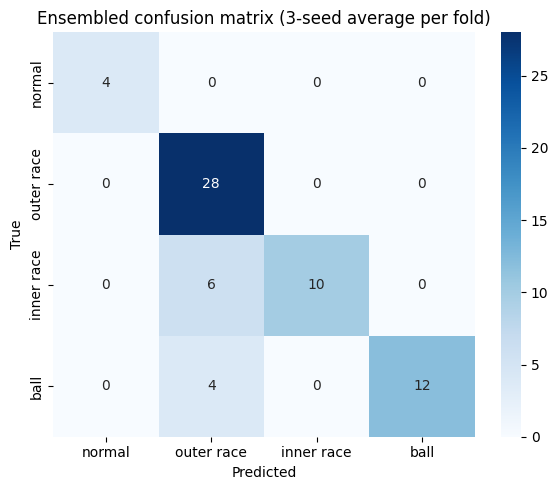

In [12]:
print('\n--- Ensembled evaluation (averaging all 3 seeds per fold) ---')
ensemble_truth, ensemble_predictions = [], []

for held_out_load in [0, 1, 2, 3]:
    loads = np.asarray([load_condition_from_group_id(g) for g in group_ids])
    val_indices = np.flatnonzero(loads == held_out_load)
    val_loader = DataLoader(
        RawRecordingDataset(signals, labels, group_ids, val_indices),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_raw_recordings,
    )

    models = []
    for state in fold_models[held_out_load]:
        m = EndToEndSTFTClassifier().to(DEVICE)
        m.load_state_dict(state)
        m.eval()
        models.append(m)

    with torch.no_grad():
        for raw, lengths, targets, _ in val_loader:
            raw, lengths = raw.to(DEVICE), lengths.to(DEVICE)
            probs_sum = None
            for m in models:
                log_probs = m(raw, lengths)
                probs = torch.exp(log_probs)  # back to probabilities for averaging
                probs_sum = probs if probs_sum is None else probs_sum + probs
            averaged_probs = probs_sum / len(models)
            ensemble_truth.extend(targets.numpy())
            ensemble_predictions.extend(averaged_probs.argmax(1).cpu().numpy())

ensemble_truth, ensemble_predictions = np.asarray(ensemble_truth), np.asarray(ensemble_predictions)
print(f'Ensembled pooled accuracy: {accuracy_score(ensemble_truth, ensemble_predictions):.4f}')
print(classification_report(ensemble_truth, ensemble_predictions, labels=range(NUM_CLASSES),
                             target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(ensemble_truth, ensemble_predictions, labels=range(NUM_CLASSES))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Ensembled confusion matrix (3-seed average per fold)')
plt.tight_layout()
plt.show()

In [13]:
import shutil

shutil.make_archive(
    "deployment_checkpoints",
    "zip",
    "deployment_checkpoints"
)

'/content/deployment_checkpoints.zip'